<a href="https://colab.research.google.com/github/Sanath-cmd/Internship_ITT/blob/main/Algorithms/DL_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [97]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [98]:
class Model(nn.Module):
  def __init__(self, in_feat= 4, h1 = 9, h2= 9, out_feat= 3):
    super().__init__()
    self.fc1 = nn.Linear(in_feat, h1)#creates link between layers
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, out_feat)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)
    return x


In [99]:
torch.manual_seed(42)
model = Model()

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [101]:
iris_data = load_iris()
df = pd.DataFrame(data=iris_data.data, columns=iris_data.feature_names)
df['target'] = iris_data.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [102]:
X = df.drop('target', axis=1)
y = df['target']

In [103]:
X = X.values
y = y.values

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)


In [105]:
criterion = nn.CrossEntropyLoss()# used for measuring the error in predicted values
optimizer = torch.optim.Adam(model.parameters(), lr= 0.01) #optimizer and learning rate to correct itself overtime


In [106]:
epochs= 100
losses= []
for i in range(epochs):
  y_pred = model.forward(X_train)
  loss = criterion(y_pred, y_train)
  losses.append(loss.detach().numpy())
  if i%10 ==0:
    print(f'Epoch: {i} and loss : {loss}')

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch: 0 and loss : 1.2088390588760376
Epoch: 10 and loss : 1.0243641138076782
Epoch: 20 and loss : 0.9073676466941833
Epoch: 30 and loss : 0.7146880030632019
Epoch: 40 and loss : 0.5106379985809326
Epoch: 50 and loss : 0.37458887696266174
Epoch: 60 and loss : 0.2505129873752594
Epoch: 70 and loss : 0.1489415317773819
Epoch: 80 and loss : 0.09926195442676544
Epoch: 90 and loss : 0.07977955043315887


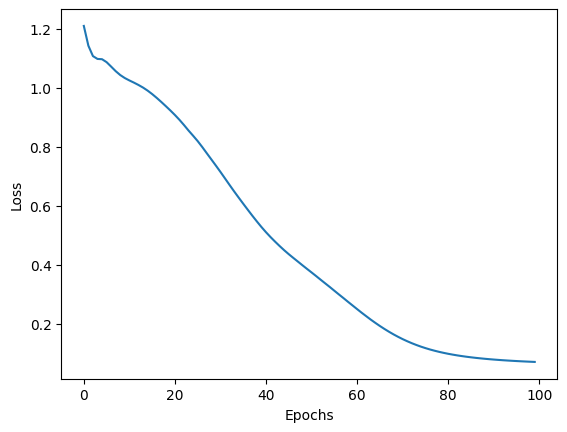

In [107]:
plt.plot(range(epochs), losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [108]:
with torch.no_grad(): #turn off back propogation
  y_eval = model.forward(X_test)
  loss = criterion(y_eval, y_test)

In [109]:
loss

tensor(0.0956)

In [110]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    if y_test[i]== 0:
      x= 'Setosa'
    elif y_test[i]== 1:
      x = 'Versicolor'
    else:
      x= 'Virginica'
    print(f'{i+1} \t {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}')
    if y_val.argmax().item()== y_test[i]:
      correct+=1

print(f"wE GOT {correct} correct")

1 	 tensor([-5.9500,  2.0166, -1.0232]) 	 1 	 1
2 	 tensor([  7.5463,   1.7760, -13.5918]) 	 0 	 0
3 	 tensor([-17.9745,  -1.1546,  12.2524]) 	 2 	 2
4 	 tensor([-5.6897,  1.9821, -1.1929]) 	 1 	 1
5 	 tensor([-6.2966,  2.2316, -1.2843]) 	 1 	 1
6 	 tensor([  7.1142,   1.6695, -12.8128]) 	 0 	 0
7 	 tensor([-1.7962,  2.3483, -4.9572]) 	 1 	 1
8 	 tensor([-9.1188,  1.2208,  2.1629]) 	 2 	 2
9 	 tensor([-7.8069,  1.3622,  1.4131]) 	 1 	 2
10 	 tensor([-3.1603,  2.3864, -3.7739]) 	 1 	 1
11 	 tensor([-8.3120,  1.3415,  1.4905]) 	 2 	 2
12 	 tensor([  6.6042,   1.4740, -11.7131]) 	 0 	 0
13 	 tensor([  7.4877,   1.6882, -13.2969]) 	 0 	 0
14 	 tensor([  6.6555,   1.5177, -11.8858]) 	 0 	 0
15 	 tensor([  7.2066,   1.6123, -12.7729]) 	 0 	 0
16 	 tensor([-5.2560,  2.2907, -2.1479]) 	 1 	 1
17 	 tensor([-12.6447,  -0.0718,   6.8722]) 	 2 	 2
18 	 tensor([-3.6516,  2.3078, -3.0773]) 	 1 	 1
19 	 tensor([-5.7333,  1.8480, -0.8420]) 	 1 	 1
20 	 tensor([-12.5141,  -0.1037,   6.8883]) 	 2 	 2
21